<a href="https://colab.research.google.com/github/isaacmutuma/federated-subset-scanning-pads/blob/main/Data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Imports
from google.colab import drive
drive.mount('/content/drive')
import os
import os.path as osp
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter,filtfilt


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
dataset_path = "/content/drive/MyDrive/pads-parkisons-dataset-folder"
os.listdir(dataset_path)

['pads-parkinsons-disease-smartwatch-dataset-1.0.0.zip', 'manifest.csv']

In [3]:


zip_path = "/content/drive/MyDrive/pads-parkisons-dataset-folder/pads-parkinsons-disease-smartwatch-dataset-1.0.0.zip"
extract_path = "/content/pads_dataset"

import zipfile
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

os.listdir(extract_path)

['pads-parkinsons-disease-smartwatch-dataset-1.0.0']

In [4]:
base_path = f"{extract_path}/pads-parkinsons-disease-smartwatch-dataset-1.0.0"
os.listdir(base_path)

['patients',
 'SHA256SUMS.txt',
 'scripts',
 'preprocessed',
 'movement',
 'LICENSE.txt',
 'questionnaire']

In [5]:
# file paths
base_path = f"{extract_path}/pads-parkinsons-disease-smartwatch-dataset-1.0.0"
timeseries_dir = f"{base_path}/movement/timeseries"
observation_dir = f"{base_path}/movement"
patients_dir = f"{base_path}/patients"

In [6]:
# load the timeseries file
def load_timeseries(filepath):
    columns = ["Time", "Accel_X", "Accel_Y", "Accel_Z", "Gyro_X", "Gyro_Y", "Gyro_Z"]
    df = pd.read_csv(filepath, header=None, names=None)
    return df

In [7]:
filepath = f"{timeseries_dir}/001_Relaxed_LeftWrist.txt"
df = load_timeseries(filepath)
print(df.head(5))
print(df.shape)

          0         1         2             3         4         5         6
0  0.000000 -0.003958  0.002360  1.746120e-03 -0.015492  0.005616  0.001034
1  0.009903 -0.004005  0.002259  8.355394e-04 -0.012276  0.005605 -0.003218
2  0.019901  0.000833  0.002225  9.437218e-04 -0.009051  0.002432 -0.002137
3  0.029907 -0.000191  0.004109  4.783000e-07 -0.008911  0.002154 -0.000931
4  0.039984  0.001769  0.004064 -1.902400e-03 -0.007830  0.000034  0.000145
(2048, 7)


In [8]:

def get_patient_label(patient_id,patients_dir):
  individual_file= f"patient_{int(patient_id):03d}.json" # the padding ensures we can enter an int without thinking about the zeros
  file_path=osp.join(patients_dir,individual_file)

  # reading the file contents
  with open(file_path) as file:
    contents = json.load(file)
    #  get the condition for each patient
    condition= contents.get("condition")

    return condition


In [9]:
label= get_patient_label(1,patients_dir)
print(label)

Healthy


In [10]:
def build_manifest(patients_dir, observation_dir, n_patients=469):
    rows = []
    for pat_num in range(1, n_patients + 1):
        patient_id = f"{pat_num:03d}"
        label = get_patient_label(pat_num, patients_dir)

        obs_path = osp.join(observation_dir, f"observation_{patient_id}.json")
        with open(obs_path) as f:
            obs_contents = json.load(f)

        for session in obs_contents["session"]:
            activity_name = session.get("record_name")
            for record in session['records']:
                left_right_wrist = record.get('device_location' )
                filename = record.get('file_name')
                rows.append({
                    "patient_id": patient_id,
                    "label": label,
                    "task": activity_name,
                    "wrist": left_right_wrist,
                    "filepath": filename
                })

    return pd.DataFrame(rows)


full_path = osp.join(base_path, "movement", row["filepath"])
df = load_timeseries(full_path)

In [11]:
manifest = build_manifest(patients_dir, observation_dir, n_patients=469)
#print(manifest.to_string(index=False))
print(manifest.shape)          # expected (469 * 11 * 2, 5) = (10318, 5)
print(manifest.label.value_counts())   # expected roughly: 291 PD-ish, 99 DD-ish, 79 HC-ish subjects worth of rows
print(manifest.isnull().sum()) # any column with nulls = a real problem to chase down
manifest.to_csv("/content/drive/MyDrive/pads-parkisons-dataset-folder/manifest.csv", index=False)



(10318, 5)
label
Parkinson's                 6072
Healthy                     1738
Other Movement Disorders    1320
Essential Tremor             616
Atypical Parkinsonism        330
Multiple Sclerosis           242
Name: count, dtype: int64
patient_id    0
label         0
task          0
wrist         0
filepath      0
dtype: int64


In [12]:
healthy_df = manifest[(manifest["label"] == "Healthy") &
                       (manifest["task"] == "Relaxed") &
                       (manifest["wrist"] == "RightWrist")]

pd_df = manifest[(manifest["label"] == "Parkinson's") &
                  (manifest["task"] == "Relaxed") &
                  (manifest["wrist"] == "RightWrist")]

healthy_row =healthy_df.iloc[0]
pd_row=pd_df.iloc[0]
print(healthy_df.value_counts())
print(pd_df.value_counts())


patient_id  label    task     wrist       filepath                             
001         Healthy  Relaxed  RightWrist  timeseries/001_Relaxed_RightWrist.txt    1
003         Healthy  Relaxed  RightWrist  timeseries/003_Relaxed_RightWrist.txt    1
021         Healthy  Relaxed  RightWrist  timeseries/021_Relaxed_RightWrist.txt    1
027         Healthy  Relaxed  RightWrist  timeseries/027_Relaxed_RightWrist.txt    1
034         Healthy  Relaxed  RightWrist  timeseries/034_Relaxed_RightWrist.txt    1
                                                                                  ..
455         Healthy  Relaxed  RightWrist  timeseries/455_Relaxed_RightWrist.txt    1
457         Healthy  Relaxed  RightWrist  timeseries/457_Relaxed_RightWrist.txt    1
459         Healthy  Relaxed  RightWrist  timeseries/459_Relaxed_RightWrist.txt    1
463         Healthy  Relaxed  RightWrist  timeseries/463_Relaxed_RightWrist.txt    1
466         Healthy  Relaxed  RightWrist  timeseries/466_Relaxed_Right

In [13]:
def load_timeseries(absfilepath):
    columns = ["Time", "Accel_X", "Accel_Y", "Accel_Z", "Gyro_X", "Gyro_Y", "Gyro_Z"]
    df = pd.read_csv(absfilepath, header=None, names=columns)
    return df

healthy_signal={}
for healthy_pat in range(len(healthy_df)):
  patient_id = healthy_df.patient_id.iloc[healthy_pat]
  filepath= healthy_df["filepath"].iloc[healthy_pat]
  absfilepath=osp.join(base_path, "movement" ,filepath)
  healthy_signal[patient_id]=load_timeseries(absfilepath)


#print(healthy_signal)


# loop to load all the pd patients real data on right hand relaxed text
pd_signal={}
for pd_pat in range(len(pd_df)):
  patient_id = pd_df.patient_id.iloc[pd_pat]
  filepath= pd_df["filepath"].iloc[pd_pat]
  absfilepath=osp.join(base_path, "movement" ,filepath)
  pd_signal[patient_id]=load_timeseries(absfilepath)
print(pd_signal)




{'004':            Time   Accel_X   Accel_Y   Accel_Z    Gyro_X    Gyro_Y    Gyro_Z
0      0.000000  0.002494  0.003593 -0.001910 -0.002130  0.008050  0.003846
1      0.009666  0.004356  0.000665 -0.000867  0.001049  0.010193  0.002784
2      0.019808  0.004270  0.000670 -0.000810  0.002127  0.009134  0.001722
3      0.029805  0.002216  0.000666  0.002156  0.001292  0.007992  0.002862
4      0.039869  0.005099 -0.000318  0.001223 -0.004022  0.005816  0.001801
...         ...       ...       ...       ...       ...       ...       ...
2043  20.565872 -0.000670  0.001686  0.001370 -0.018784 -0.008150 -0.002435
2044  20.575743  0.000391  0.004495  0.000283 -0.012373 -0.009169 -0.004561
2045  20.585691  0.002445  0.007402  0.001183 -0.000602 -0.012242 -0.003504
2046  20.595787  0.001591  0.008424  0.000163  0.010092 -0.014271 -0.003507
2047  20.606153  0.002672  0.007572  0.000164  0.017530 -0.011023 -0.003507

[2048 rows x 7 columns], '005':            Time   Accel_X   Accel_Y   Accel_Z  

In [14]:
'''absfilepath=osp.join(base_path, "movement", pd_row["filepath"])
pd_signal =load_timeseries(absfilepath)
print(pd_signal)'''

'absfilepath=osp.join(base_path, "movement", pd_row["filepath"])\npd_signal =load_timeseries(absfilepath)\nprint(pd_signal)'

In [15]:
"""# with healthy and pd signal we need to now magnitude that just move motion regradless of the direction x,y or z

magnitude_healthy={}
for patient_id,signal in healthy_signal.items():
  mag=np.sqrt(signal["Accel_X" ]**2
        +signal["Accel_Y"]**2
        +signal["Accel_Z"]**2)
  magnitude_healthy[patient_id]=mag
averaged_values = [np.mean(v) for v in magnitude_healthy.values()]

magnitude_pd={}
for patient_id,signal in pd_signal.items():
  mag=np.sqrt(signal["Accel_X" ]**2
        +signal["Accel_Y"]**2
        +signal["Accel_Z"]**2)
  magnitude_pd[patient_id]=mag


# plot of both signals
plt.figure(figsize=(12, 8))
plt.bar( magnitude_healthy.keys(),averaged_values )

plt.xlabel('Time / Sample Index')
plt.ylabel('Magnitude')
plt.title('Magnitude Comparison Over Time')
plt.legend()
plt.show()

"""





'# with healthy and pd signal we need to now magnitude that just move motion regradless of the direction x,y or z\n\nmagnitude_healthy={}\nfor patient_id,signal in healthy_signal.items():\n  mag=np.sqrt(signal["Accel_X" ]**2\n        +signal["Accel_Y"]**2\n        +signal["Accel_Z"]**2)\n  magnitude_healthy[patient_id]=mag\naveraged_values = [np.mean(v) for v in magnitude_healthy.values()]\n\nmagnitude_pd={}\nfor patient_id,signal in pd_signal.items():\n  mag=np.sqrt(signal["Accel_X" ]**2\n        +signal["Accel_Y"]**2\n        +signal["Accel_Z"]**2)\n  magnitude_pd[patient_id]=mag\n\n\n# plot of both signals\nplt.figure(figsize=(12, 8))\nplt.bar( magnitude_healthy.keys(),averaged_values )\n\nplt.xlabel(\'Time / Sample Index\')\nplt.ylabel(\'Magnitude\')\nplt.title(\'Magnitude Comparison Over Time\')\nplt.legend()\nplt.show()\n\n'

In [16]:

def bandpass_filter_df(df, fs=100.0, lowcut=1.0, highcut=20.0, order=3):
  nyq = 0.5 * fs
  low = lowcut / nyq
  high = highcut / nyq
  b, a = butter(3,[low, high], btype='band')

  df_new=df.copy()
  signal_columns = ['Accel_X', 'Accel_Y', 'Accel_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z']
  for col in signal_columns:
    filtered_values = filtfilt(b, a, df[col].values)
    df_new[col] = filtered_values
  return df_new




In [17]:
# fltered signal is a df

healthy_filtered={}
for patient_id, df in healthy_signal.items():
  # store the result of the function
   filtered_signal=bandpass_filter_df(df,fs=100.0, lowcut=1.0, highcut=20.0, order=3)
   healthy_filtered[patient_id]=filtered_signal

pd_filtered={}
for patient_id,df in pd_signal.items():
  filtered_signal=bandpass_filter_df(df, fs=100.0, lowcut=1.0, highcut=20.0, order=3)
  pd_filtered[patient_id]=filtered_signal


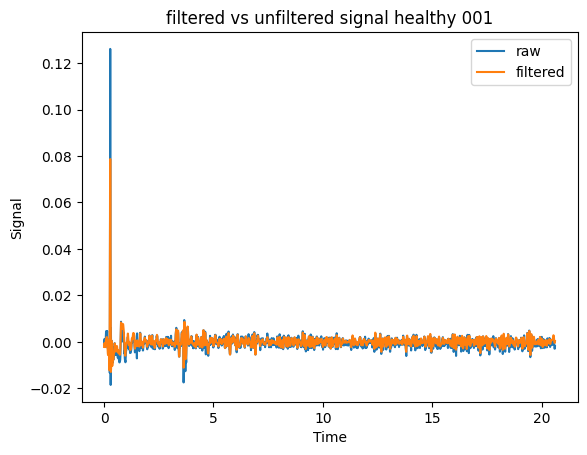

In [18]:
plt.plot(healthy_signal['001']['Time'],healthy_signal['001']['Accel_X'],label='raw')
plt.plot(healthy_signal['001']['Time'],healthy_filtered['001']['Accel_X'], label='filtered')

plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('filtered vs unfiltered signal healthy 001')
plt.legend()
plt.show()


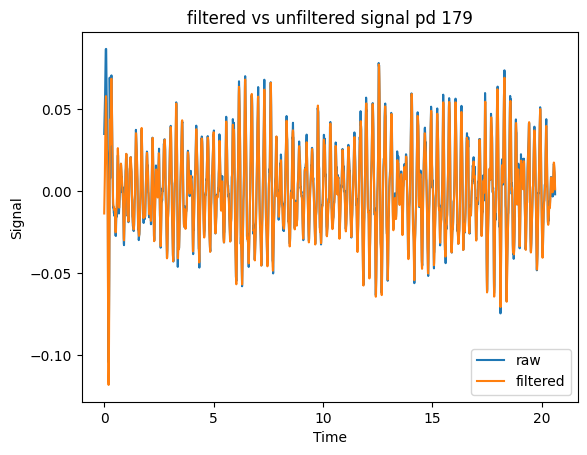

In [19]:
plt.plot(pd_signal['179']['Time'],pd_signal['179']['Accel_X'],label='raw')
plt.plot(pd_signal['179']['Time'],pd_filtered['179']['Accel_X'], label='filtered')

plt.xlabel('Time')
plt.ylabel('Signal')
plt.title('filtered vs unfiltered signal pd 179')
plt.legend()
plt.show()

In [20]:
# windowing out the input for the cnn
window_lookup={}
for patient_id,signal in healthy_filtered.items():
  n_windows= len(signal)//200
  for window_i in range(n_windows):
      start_row = window_i * 200
      end_row = start_row + 200
      window = signal.iloc[start_row:end_row]
      window_lookup[(patient_id,window_i)]=window


print(len(window_lookup))              # expect ~79 subjects × 10 windows ≈ 790
print(window_lookup[("001", 0)].shape) # expect (200, 7)
print(window_lookup[("001", 9)].shape) # expect (200, 7) — last valid window



790
(200, 7)
(200, 7)


In [21]:
# splitting the filtered pd data into 10 windows
# this stored in a look up dict where the key is patient_id and window number
#the value is the 200(2sec) window recorded per patient per window


#window_lookup={}
for patient_id,signal in pd_filtered.items():
  n_windows=len(signal)//200
  for window_i in range(n_windows):
    start_row = 200* window_i
    end_row= start_row +200
    window = signal.iloc[start_row:end_row]
    window_lookup[(patient_id,window_i)]=window



In [22]:
#metadata table
# connects the patient_id ,window_i to a label
# so three items on this table 2 from a dict 1 from the label function call
window_metadata=[]
for(patient_id,window_i),window in window_lookup.items():
  label=get_patient_label(patient_id, patients_dir)
  window_metadata.append({
      "patient_id": patient_id,
      "window_no":window_i,
      "label": label
  })
# converting a list of dict into a df
window_metadata_df = pd.DataFrame(window_metadata)

print(window_metadata_df.shape)      # expect ~790 (HC) + however many PD windows, 3 columns
print(window_metadata_df.label.value_counts())
window_metadata_df.head()


(3550, 3)
label
Parkinson's    2760
Healthy         790
Name: count, dtype: int64


,patient_id,window_no,label
0,001,0,Healthy
1,001,1,Healthy
2,001,2,Healthy
3,001,3,Healthy
4,001,4,Healthy


In [23]:
print(len(window_lookup))
print(len(pd_filtered))
one_id = list(pd_filtered.keys())[0]
print(len(pd_filtered[one_id]))
print(len(window_lookup))   # expect (79 + 276) * 10 ≈ 3550

3550
276
2048
3550
